In [1]:
from clean import *
import mplfinance as mpf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_min, spec = import_dataset()

Dataset 'gc1' imported with 4565856 rows


In [3]:
def plot_advanced_market_diagnostics(df, asset_name="Future"):
    # 1. Preparación de datos y asegurar índice temporal
    df_diag = df.copy()
    
    # Limpieza de nombres por si acaso
    df_diag.columns = df_diag.columns.str.strip().str.lower()
    
    if 'datetime' not in df_diag.columns:
        raise ValueError("El DataFrame debe contener una columna 'datetime'")
    
    # Creamos columnas auxiliares antes de cambiar el índice
    df_diag['hour'] = df_diag['datetime'].dt.hour
    df_diag['day_name'] = df_diag['datetime'].dt.day_name()
    df_diag['volatility'] = df_diag['high'] - df_diag['low']
    
    # ESTABLECER DATETIME COMO ÍNDICE (Soluciona el TypeError)
    df_diag = df_diag.set_index('datetime')
    
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    
    fig = plt.figure(figsize=(20, 15))
    plt.suptitle(f"Diagnóstico Avanzado: {asset_name}", fontsize=20, y=0.98)

    # --- 1. HEATMAP DE VOLATILIDAD ---
    plt.subplot(3, 1, 1)
    heatmap_data = df_diag.groupby(['day_name', 'hour'])['volatility'].mean().unstack()
    # Reordenamos días y rellenamos horas faltantes con 0
    heatmap_data = heatmap_data.reindex(days_order).fillna(0)
    sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Volatilidad (Ticks)'})
    plt.title("Mapa de Calor: Volatilidad por Hora y Día")

    # --- 2. AUTOCORRELACIÓN ---
    plt.subplot(3, 2, 3)
    # Calculamos retornos sobre el cierre
    returns = np.log(df_diag['close'] / df_diag['close'].shift(1)).dropna()
    # Tomamos una muestra para que no sea lento (últimas 10k velas)
    pd.plotting.autocorrelation_plot(returns.tail(10000), ax=plt.gca())
    plt.title("Autocorrelación de Retornos (¿Hay patrones repetitivos?)")
    plt.ylim(-0.05, 0.05) 

    # --- 3. GAP ANALYSIS (Ahora sí funciona el resample) ---
    plt.subplot(3, 2, 4)
    # Agrupamos por día (D) para comparar apertura vs cierre anterior
    df_daily = df_diag.resample('D').agg({'open': 'first', 'close': 'last'}).dropna()
    df_daily['gap'] = df_daily['open'] - df_daily['close'].shift(1)
    
    sns.histplot(df_daily['gap'].dropna(), kde=True, color='purple', bins=50)
    plt.title("Distribución de Gaps de Apertura")
    plt.xlabel("Tamaño del Gap (Ticks)")

    # --- 4. VOLUMEN VS VOLATILIDAD ---
    plt.subplot(3, 1, 3)
    hourly_stats = df_diag.groupby('hour').agg({'volume': 'mean', 'volatility': 'mean'})
    ax1 = sns.barplot(x=hourly_stats.index, y=hourly_stats['volume'], color='skyblue', alpha=0.5)
    ax1.set_ylabel('Volumen Promedio', color='blue')
    ax2 = ax1.twinx()
    sns.lineplot(x=hourly_stats.index, y=hourly_stats['volatility'], marker='o', color='red', ax=ax2)
    ax2.set_ylabel('Volatilidad Promedio', color='red')
    plt.title("Esfuerzo (Volumen) vs Resultado (Volatilidad)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

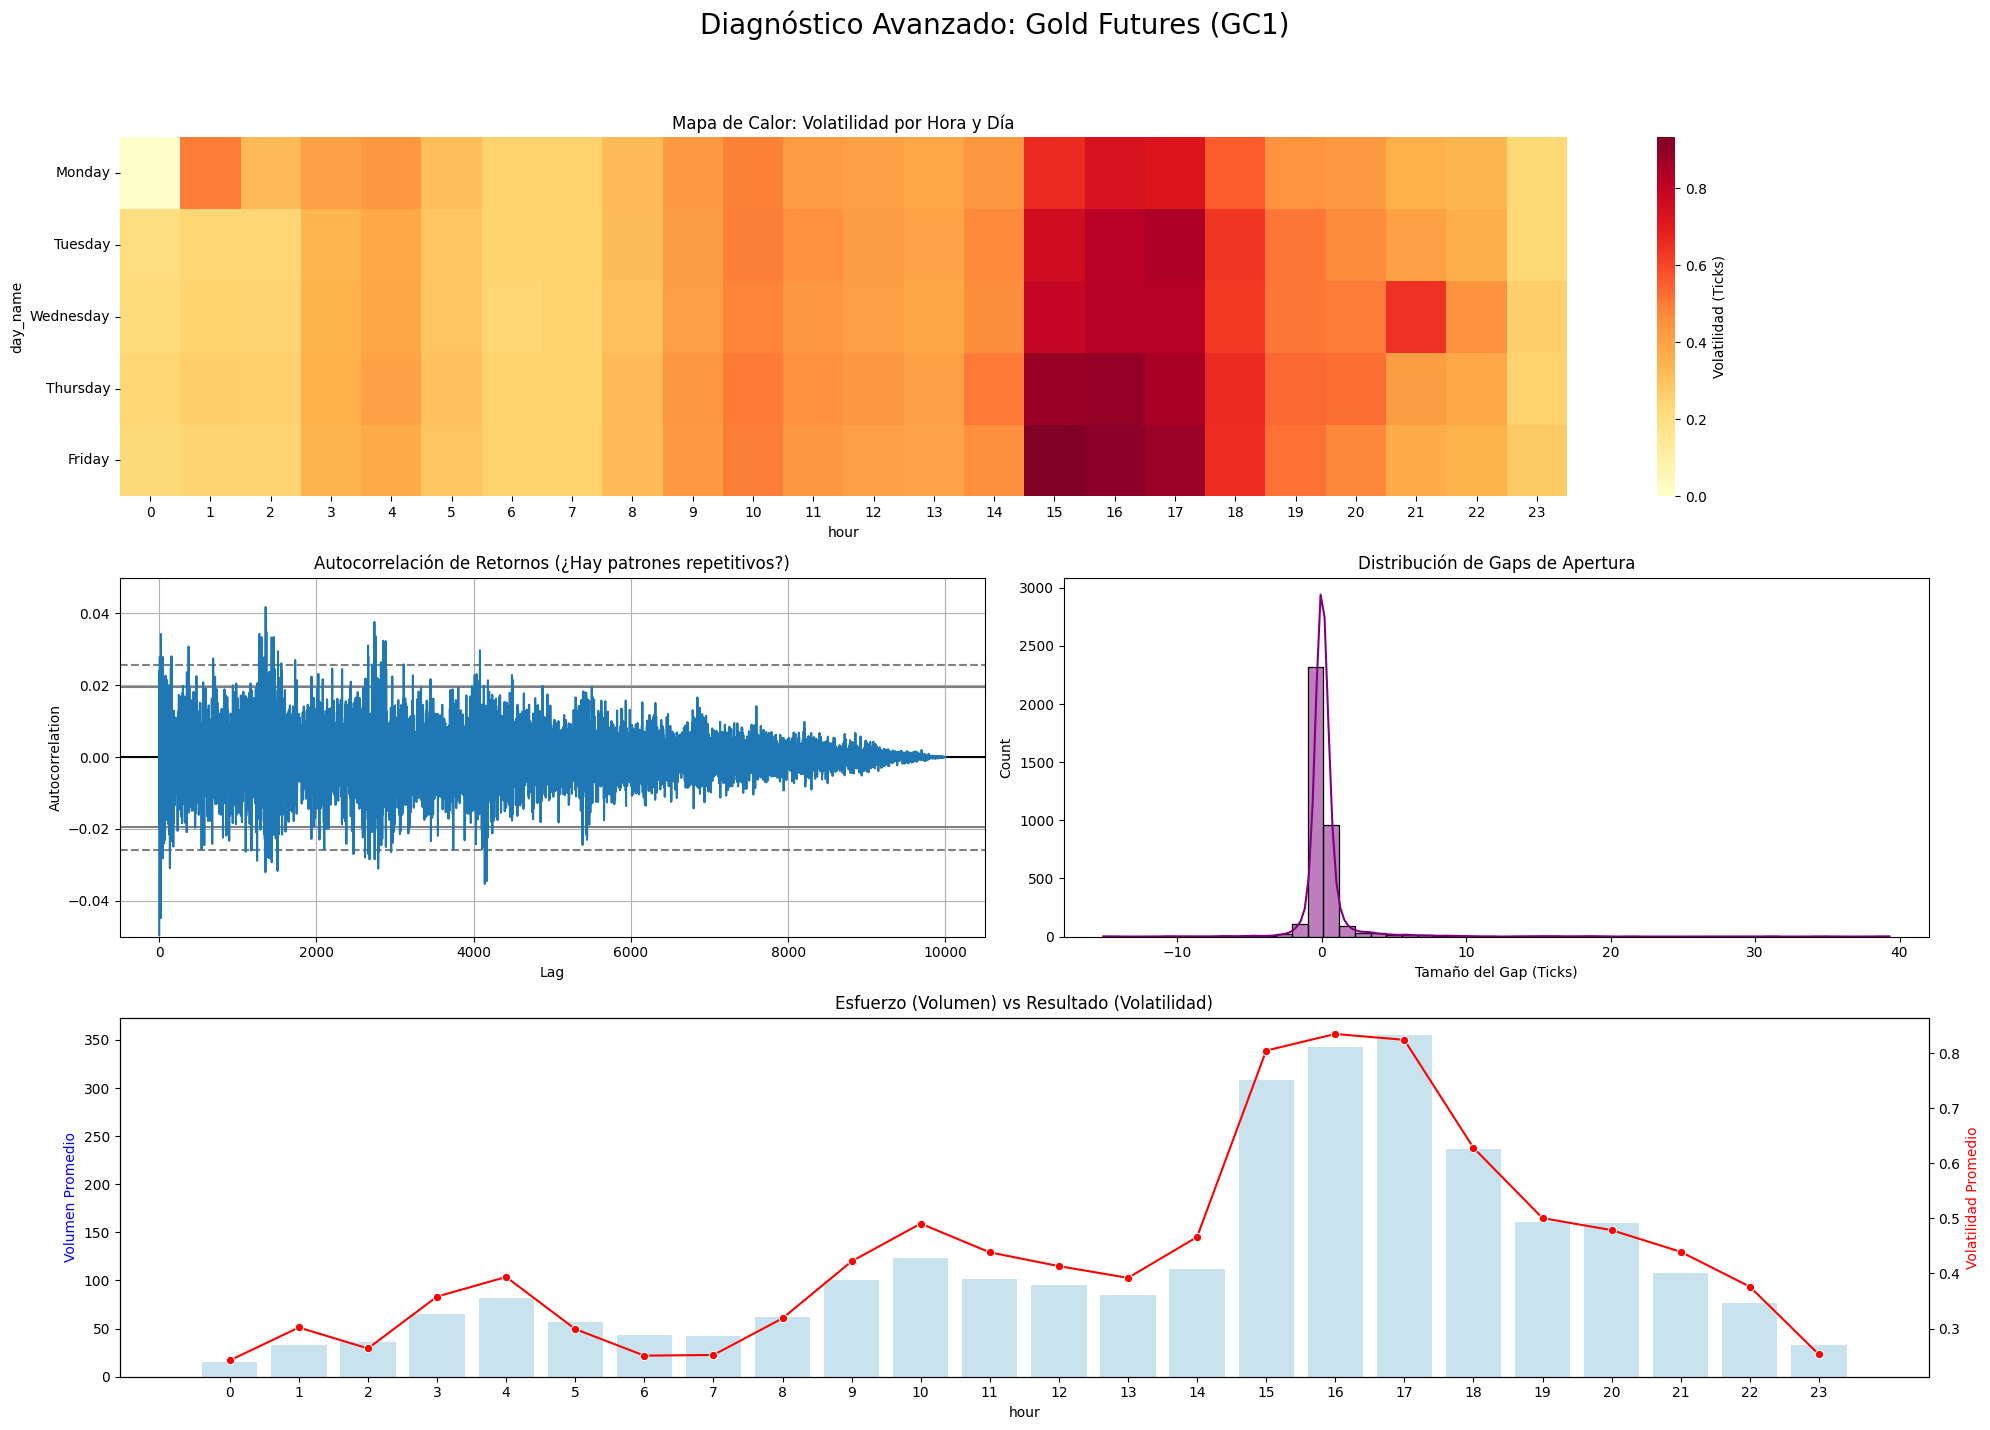

In [4]:
plot_advanced_market_diagnostics(df_min, asset_name="Gold Futures (GC1)")

In [5]:
def plot_complete_market_analysis(df, asset_name="Future"):
    df_diag = df.copy()
    df_diag.columns = df_diag.columns.str.strip().str.lower()
    
    if 'datetime' in df_diag.columns:
        df_diag = df_diag.set_index('datetime')
    
    df_diag['hour'] = df_diag.index.hour
    df_diag['day_name'] = df_diag.index.day_name()
    df_diag['volatility'] = df_diag['high'] - df_diag['low']
    
    # Orden natural de la semana incluyendo fin de semana para detectar errores
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Aumentamos el tamaño para acomodar 5 filas de gráficos
    fig = plt.figure(figsize=(20, 32))
    gs = fig.add_gridspec(5, 2)
    plt.suptitle(f"MEGA-DASHBOARD TÉCNICO: {asset_name}", fontsize=22, y=0.99, fontweight='bold')

    # --- FILA 1: PRECIO HISTÓRICO COMPLETO ---
    ax0 = fig.add_subplot(gs[0, :])
    df_daily_price = df_diag.resample('D').agg({'close': 'last'}).dropna()
    ax0.plot(df_daily_price.index, df_daily_price['close'], color='darkblue', linewidth=1.5)
    ax0.set_title("Historial Completo de Precios (Cierre Diario)", fontsize=14)
    ax0.grid(alpha=0.3)

    # --- FILA 2: ACTIVIDAD (VELAS) VS VOLUMEN (CONTRATOS) ---
    # Por Hora
    ax1 = fig.add_subplot(gs[1, 0])
    stats_hour = df_diag.groupby('hour').agg({'volume': 'sum', 'hour': 'count'}).rename(columns={'hour': 'count'})
    sns.barplot(x=stats_hour.index, y=stats_hour['count'], ax=ax1, color='skyblue', alpha=0.6, label='Nº Velas')
    ax1_2 = ax1.twinx()
    sns.lineplot(x=stats_hour.index, y=stats_hour['volume'], ax=ax1_2, color='darkblue', marker='o', label='Vol. Total')
    ax1.set_title("Frecuencia de Datos vs Volumen por Hora")
    
    # Por Día
    ax2 = fig.add_subplot(gs[1, 1])
    stats_day = df_diag.groupby('day_name').agg({'volume': 'sum', 'day_name': 'count'}).rename(columns={'day_name': 'count'}).reindex(days_order)
    sns.barplot(x=stats_day.index, y=stats_day['count'], ax=ax2, color='lightgreen', alpha=0.6)
    ax2_2 = ax2.twinx()
    sns.lineplot(x=stats_day.index, y=stats_day['volume'], ax=ax2_2, color='darkgreen', marker='o')
    ax2.set_title("Frecuencia de Datos vs Volumen por Día (Detecta Sáb/Dom)")

    # --- FILA 3: ESFUERZO (VOLUMEN) VS RESULTADO (VOLATILIDAD) ---
    ax3 = fig.add_subplot(gs[2, :])
    hourly_stats = df_diag.groupby('hour').agg({'volume': 'mean', 'volatility': 'mean'})
    ax3_bar = sns.barplot(x=hourly_stats.index, y=hourly_stats['volume'], color='skyblue', alpha=0.5, ax=ax3)
    ax3_bar.set_ylabel('Esfuerzo: Volumen Promedio (Contratos)', color='blue')
    ax3_line = ax3.twinx()
    sns.lineplot(x=hourly_stats.index, y=hourly_stats['volatility'], marker='o', color='red', ax=ax3_line)
    ax3_line.set_ylabel('Resultado: Volatilidad Promedio (Ticks)', color='red')
    ax3.set_title("Análisis Wyckoff: Esfuerzo vs Resultado por Hora")

    # --- FILA 4: HEATMAP DE VOLATILIDAD COMPLETO ---
    ax4 = fig.add_subplot(gs[3, :])
    heatmap_data = df_diag.groupby(['day_name', 'hour'])['volatility'].mean().unstack()
    heatmap_data = heatmap_data.reindex(days_order).fillna(0)
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Ticks'})
    ax4.set_title("Heatmap: Volatilidad en toda la semana (Detecta ruido en fines de semana)")

    # --- FILA 5: AUTOCORRELACIÓN Y GAPS ---
    ax5 = fig.add_subplot(gs[4, 0])
    returns = np.log(df_diag['close'] / df_diag['close'].shift(1)).dropna()
    pd.plotting.autocorrelation_plot(returns.tail(10000), ax=ax5)
    ax5.set_title("Autocorrelación (Memoria del Mercado)")
    ax5.set_ylim(-0.05, 0.05)

    ax6 = fig.add_subplot(gs[4, 1])
    df_gap = df_diag.resample('D').agg({'open': 'first', 'close': 'last'}).dropna()
    df_gap['gap'] = df_gap['open'] - df_gap['close'].shift(1)
    sns.histplot(df_gap['gap'].dropna(), kde=True, color='purple', ax=ax6)
    ax6.set_title("Distribución de Gaps (Apertura - Cierre Anterior)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

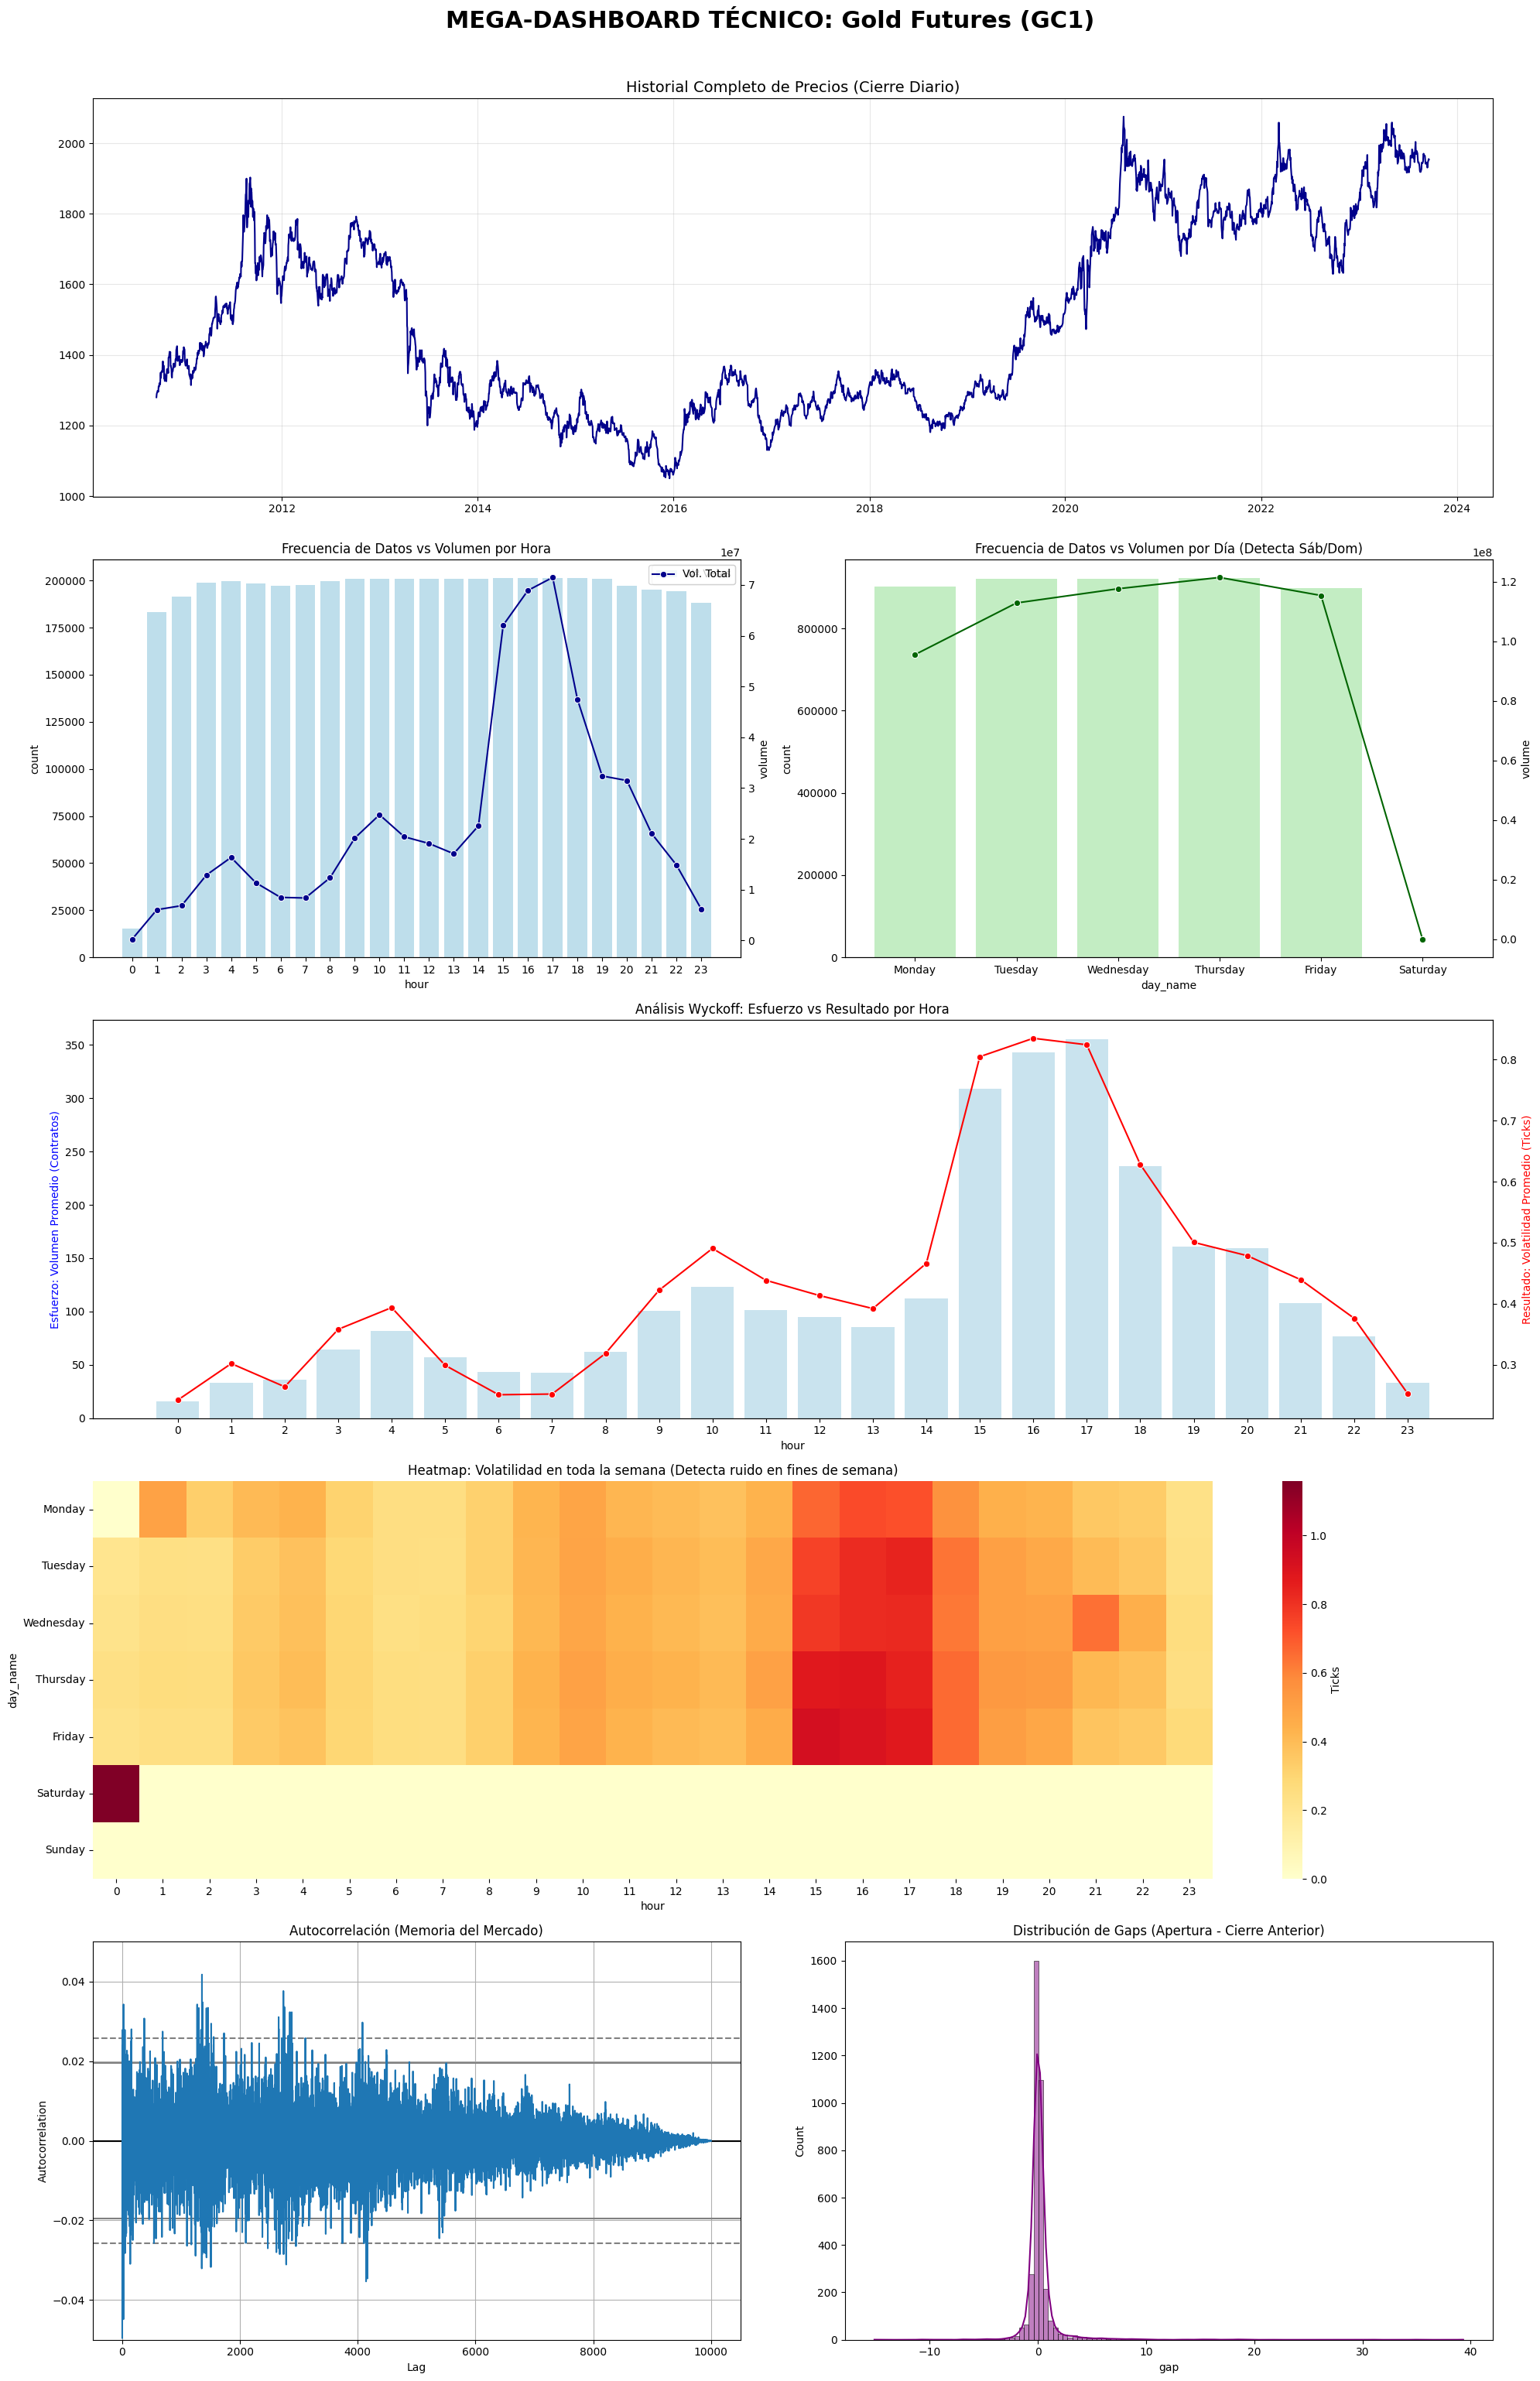

In [6]:
plot_complete_market_analysis(df_min, asset_name="Gold Futures (GC1)")

In [7]:
df_min_clean = clean(df_min)

Limpieza gc1 completada. Filas restantes: 4518540


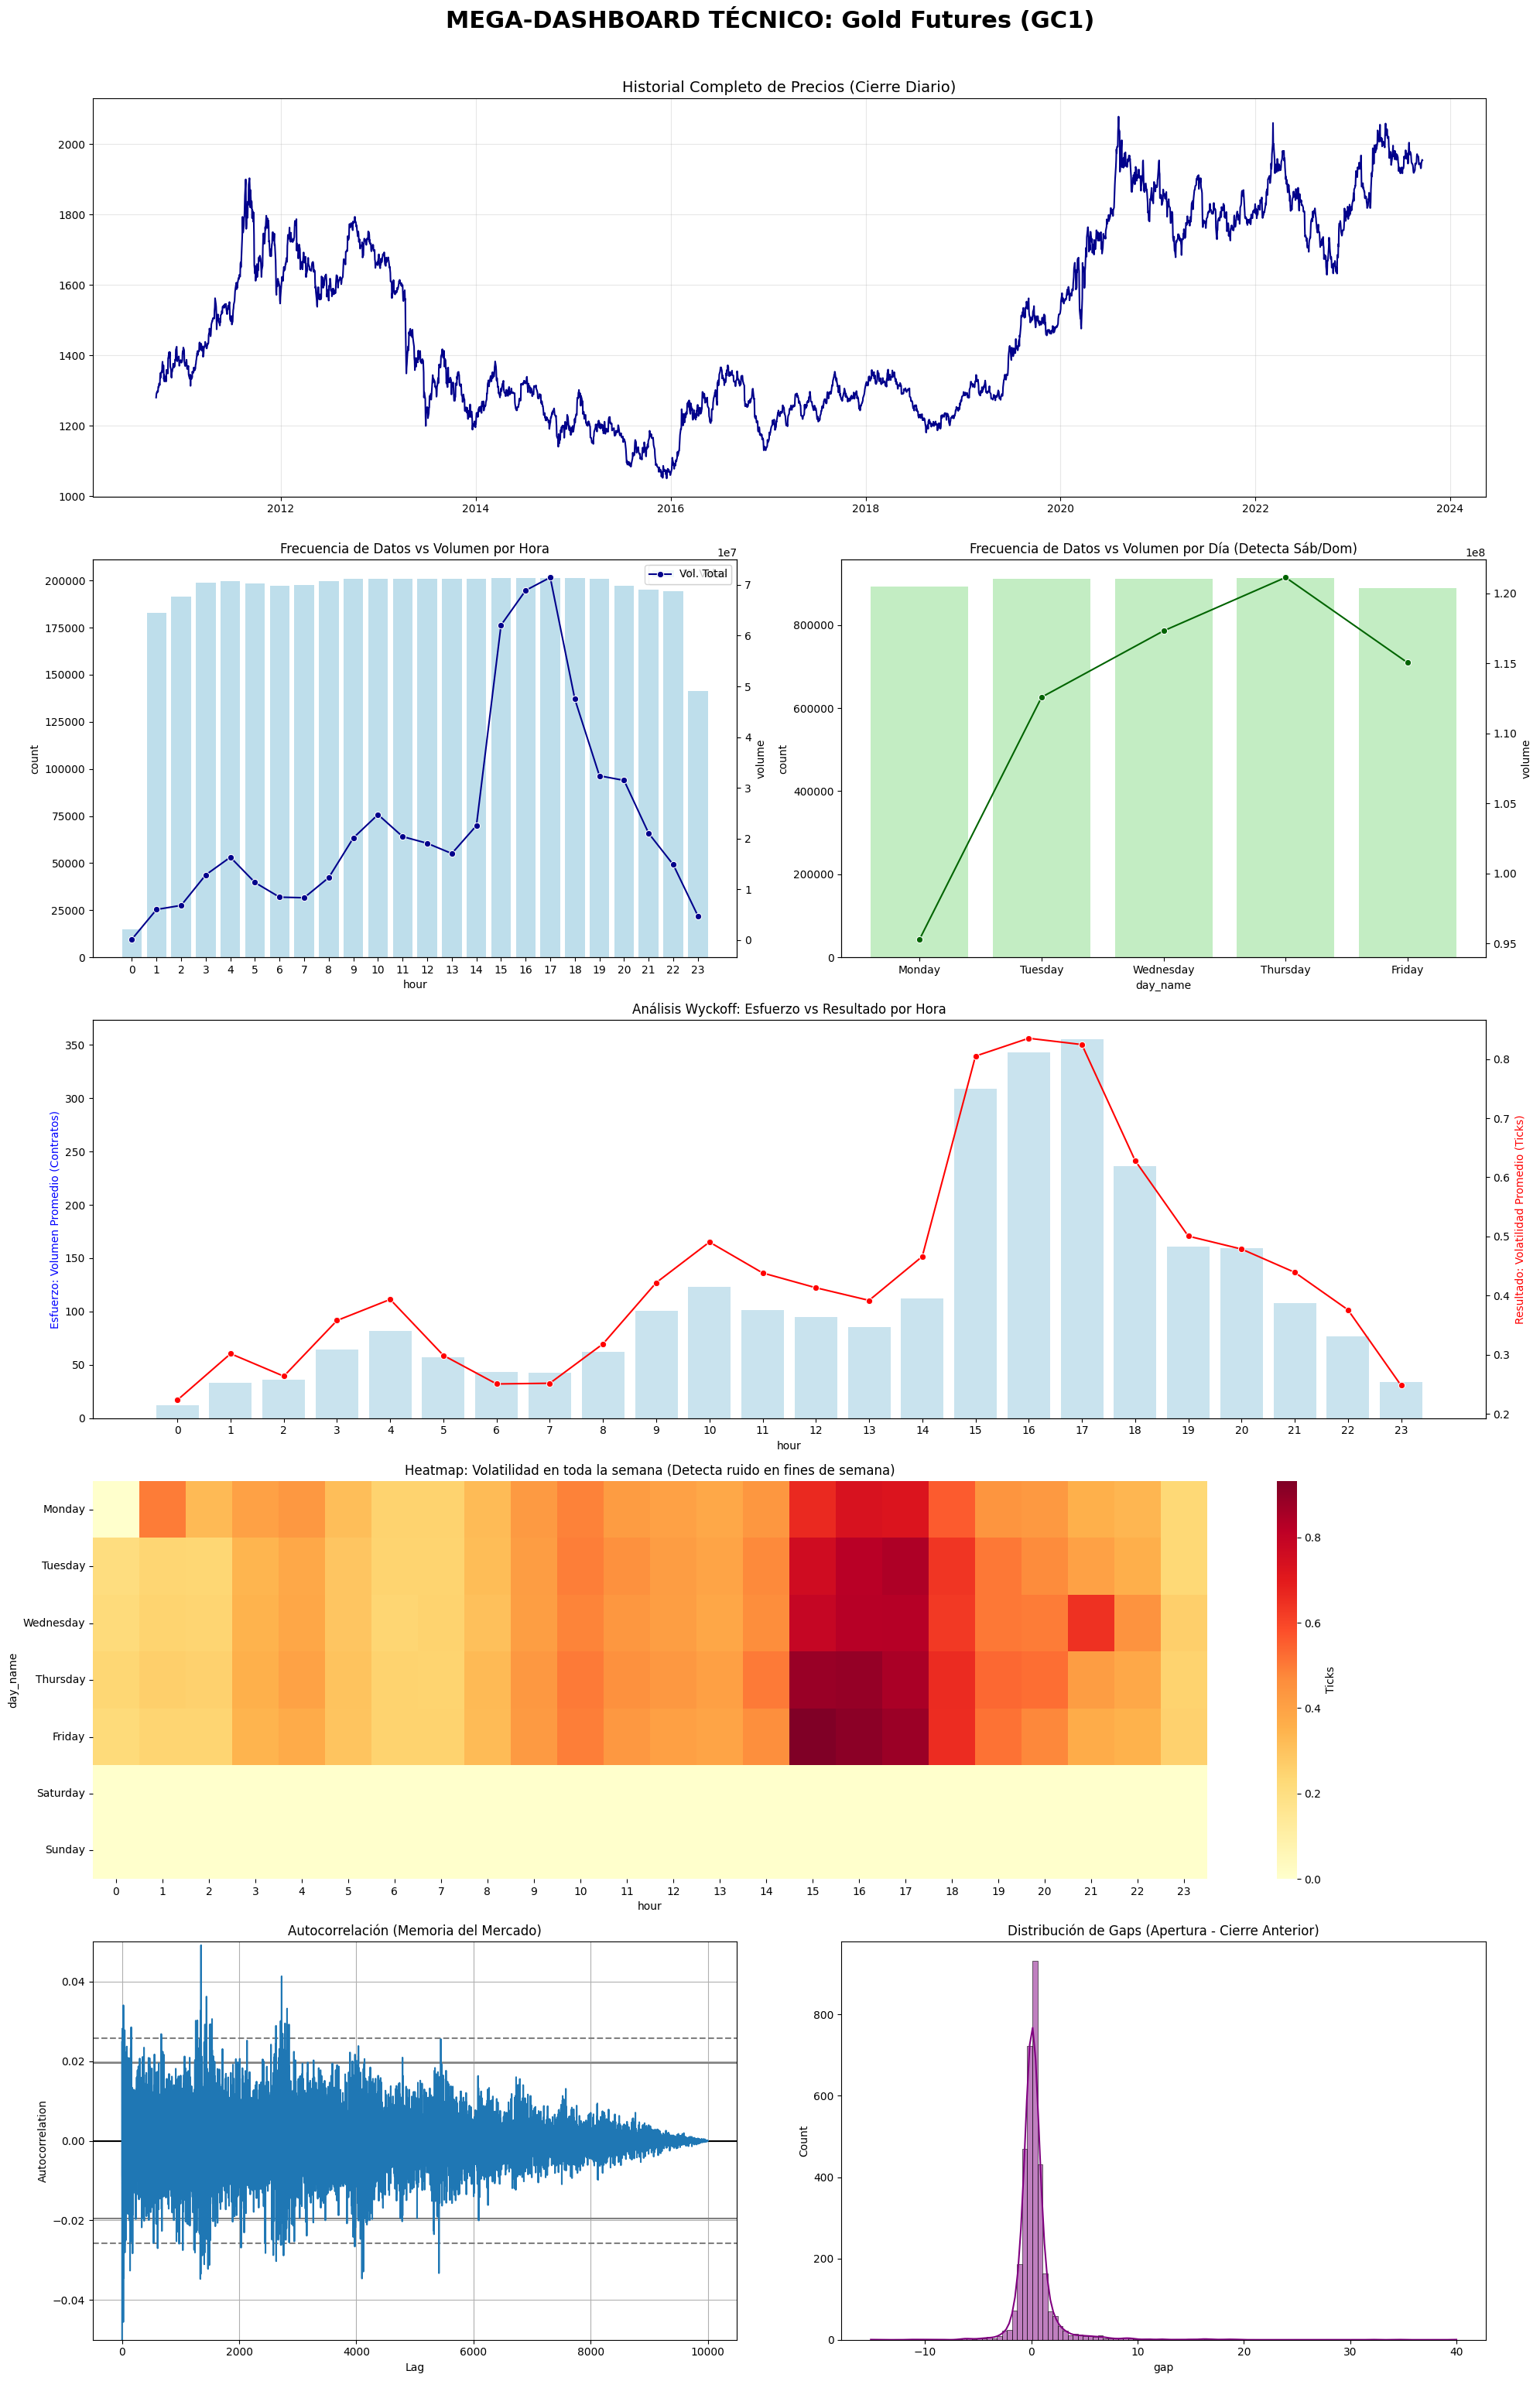

In [8]:
plot_complete_market_analysis(df_min_clean, asset_name="Gold Futures (GC1)")

In [9]:
def plot_complete_market_analysis_v3(df, asset_name="Future", tick_size=0.1):
    df_diag = df.copy()
    df_diag.columns = df_diag.columns.str.strip().str.lower()
    
    if 'datetime' in df_diag.columns:
        df_diag = df_diag.set_index('datetime')
    
    # --- CÁLCULOS BASADOS EN TICKS ---
    df_diag['hour'] = df_diag.index.hour
    df_diag['day_name'] = df_diag.index.day_name()
    # Rango en Ticks: cuántos saltos mínimos hubo en la vela
    df_diag['ticks_range'] = (df_diag['high'] - df_diag['low']) / tick_size
    # Esfuerzo por Tick: Volumen / Ticks (¿Cuántos contratos para mover 1 tick?)
    df_diag['vol_per_tick'] = df_diag['volume'] / (df_diag['ticks_range'] + 0.1) # +0.1 evitas división por cero
    
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Subimos a 6 filas para que no quede apretado
    fig = plt.figure(figsize=(20, 38))
    gs = fig.add_gridspec(7, 2)
    plt.suptitle(f"MEGA-DASHBOARD TÉCNICO & MICROESTRUCTURA: {asset_name}", fontsize=22, y=0.99, fontweight='bold')

    # --- FILA 1: PRECIO HISTÓRICO ---
    ax0 = fig.add_subplot(gs[0, :])
    df_daily = df_diag.resample('D').agg({'close': 'last'}).dropna()
    ax0.plot(df_daily.index, df_daily['close'], color='#1a508b', linewidth=1.5)
    ax0.set_title("Evolución Histórica (Precio de Cierre)", fontsize=14)

    # --- FILA 2: ACTIVIDAD VS VOLUMEN TOTAL ---
    ax1 = fig.add_subplot(gs[1, 0])
    stats_h = df_diag.groupby('hour').agg({'volume': 'sum', 'hour': 'count'}).rename(columns={'hour': 'count'})
    sns.barplot(x=stats_h.index, y=stats_h['count'], ax=ax1, color='skyblue', alpha=0.4)
    ax1_t = ax1.twinx(); sns.lineplot(x=stats_h.index, y=stats_h['volume'], ax=ax1_t, color='navy', marker='s')
    ax1.set_title("Nº de Velas vs Volumen Total por Hora")

    ax2 = fig.add_subplot(gs[1, 1])
    stats_d = df_diag.groupby('day_name').agg({'volume': 'sum', 'day_name': 'count'}).reindex(days_order)
    sns.barplot(x=stats_d.index, y=stats_d['day_name'], ax=ax2, color='lightgreen', alpha=0.4)
    ax2_t = ax2.twinx(); sns.lineplot(x=stats_d.index, y=stats_d['volume'], ax=ax2_t, color='darkgreen', marker='s')
    ax2.set_title("Integridad de Datos vs Volumen por Día")

    # --- FILA 3: ANÁLISIS WYCKOFF (ESFUERZO VS RESULTADO) ---
    ax3 = fig.add_subplot(gs[2, :])
    h_stats = df_diag.groupby('hour').agg({'volume': 'mean', 'ticks_range': 'mean'})
    sns.barplot(x=h_stats.index, y=h_stats['volume'], color='skyblue', alpha=0.5, ax=ax3)
    ax3_t = ax3.twinx(); sns.lineplot(x=h_stats.index, y=h_stats['ticks_range'], marker='o', color='red', ax=ax3_t)
    ax3.set_ylabel('Volumen Promedio', color='blue'); ax3_t.set_ylabel('Rango Medio (en Ticks)', color='red')
    ax3.set_title("Esfuerzo (Volumen) vs Resultado (Movimiento en Ticks)")

    # --- FILA 4: NUEVA - MICROESTRUCTURA DE TICKS ---
    # Distribución de Ticks por Vela
    ax4 = fig.add_subplot(gs[3, 0])
    sns.histplot(df_diag['ticks_range'], bins=50, kde=True, color='orange', ax=ax4)
    ax4.set_title("Distribución de Ticks por Vela (Volatilidad Local)")
    
    # Intensidad Institucional (Volumen por Tick)
    ax5 = fig.add_subplot(gs[3, 1])
    h_vol_tick = df_diag.groupby('hour')['vol_per_tick'].mean()
    sns.lineplot(x=h_vol_tick.index, y=h_vol_tick.values, marker='d', color='purple', ax=ax5)
    ax5.set_title("Esfuerzo por Tick (Contratos necesarios para mover 1 tick)")
    ax5.set_ylabel("Contratos / Tick")

    # --- FILA 5: HEATMAP DE TICKS ---
    ax6 = fig.add_subplot(gs[4, :])
    hmap_ticks = df_diag.groupby(['day_name', 'hour'])['ticks_range'].mean().unstack().reindex(days_order).fillna(0)
    sns.heatmap(hmap_ticks, cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Ticks'})
    ax6.set_title("Heatmap: Rango Medio de Ticks por Hora/Día")

    # --- FILA 6: AUTOCORRELACIÓN Y GAPS ---
    ax7 = fig.add_subplot(gs[5, 0])
    pd.plotting.autocorrelation_plot(df_diag['close'].resample('h').last().diff().dropna().tail(5000), ax=ax7)
    ax7.set_ylim(-0.1, 0.1); ax7.set_title("Autocorrelación de Cambios en Ticks")

    ax8 = fig.add_subplot(gs[5, 1])
    sns.histplot(df_diag['ticks_range'].tail(2000), cumulative=True, stat="density", element="step", fill=False, ax=ax8)
    ax8.set_title("Probabilidad Acumulada de Rango de Ticks")

    # --- COLUMNAS DERIVADAS DE TICKS PARA TU LSTM ---
    # 1. Velocidad del Mercado (Ticks por segundo/minuto)
    df_diag['speed'] = df_diag['ticks_range'] / 1 # asumiendo velas de 1min
    
    # 2. Intensidad de Volumen (Volumen / Ticks)
    # Indica si el movimiento es "ligero" (retail) o "pesado" (institucional)
    df_diag['intensity'] = df_diag['volume'] / (df_diag['ticks_range'] + 0.1)
    
    # --- GRÁFICAS SUGERIDAS ---
    # Fila extra de Microestructura
    ax_new1 = fig.add_subplot(gs[6, 0])
    sns.kdeplot(df_diag['intensity'], fill=True, color="purple", ax=ax_new1)
    ax_new1.set_title("Densidad de Intensidad Institucional (Contratos/Tick)")
    
    ax_new2 = fig.add_subplot(gs[6, 1])
    df_diag.groupby('hour')['speed'].mean().plot(kind='bar', ax=ax_new2, color='orange')
    ax_new2.set_title("Velocidad Media del Precio por Hora (Ticks/Min)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# Para GC1 el tick_size suele ser 0.1
# plot_complete_market_analysis_v3(df_ready, asset_name="Gold Futures", tick_size=0.1)

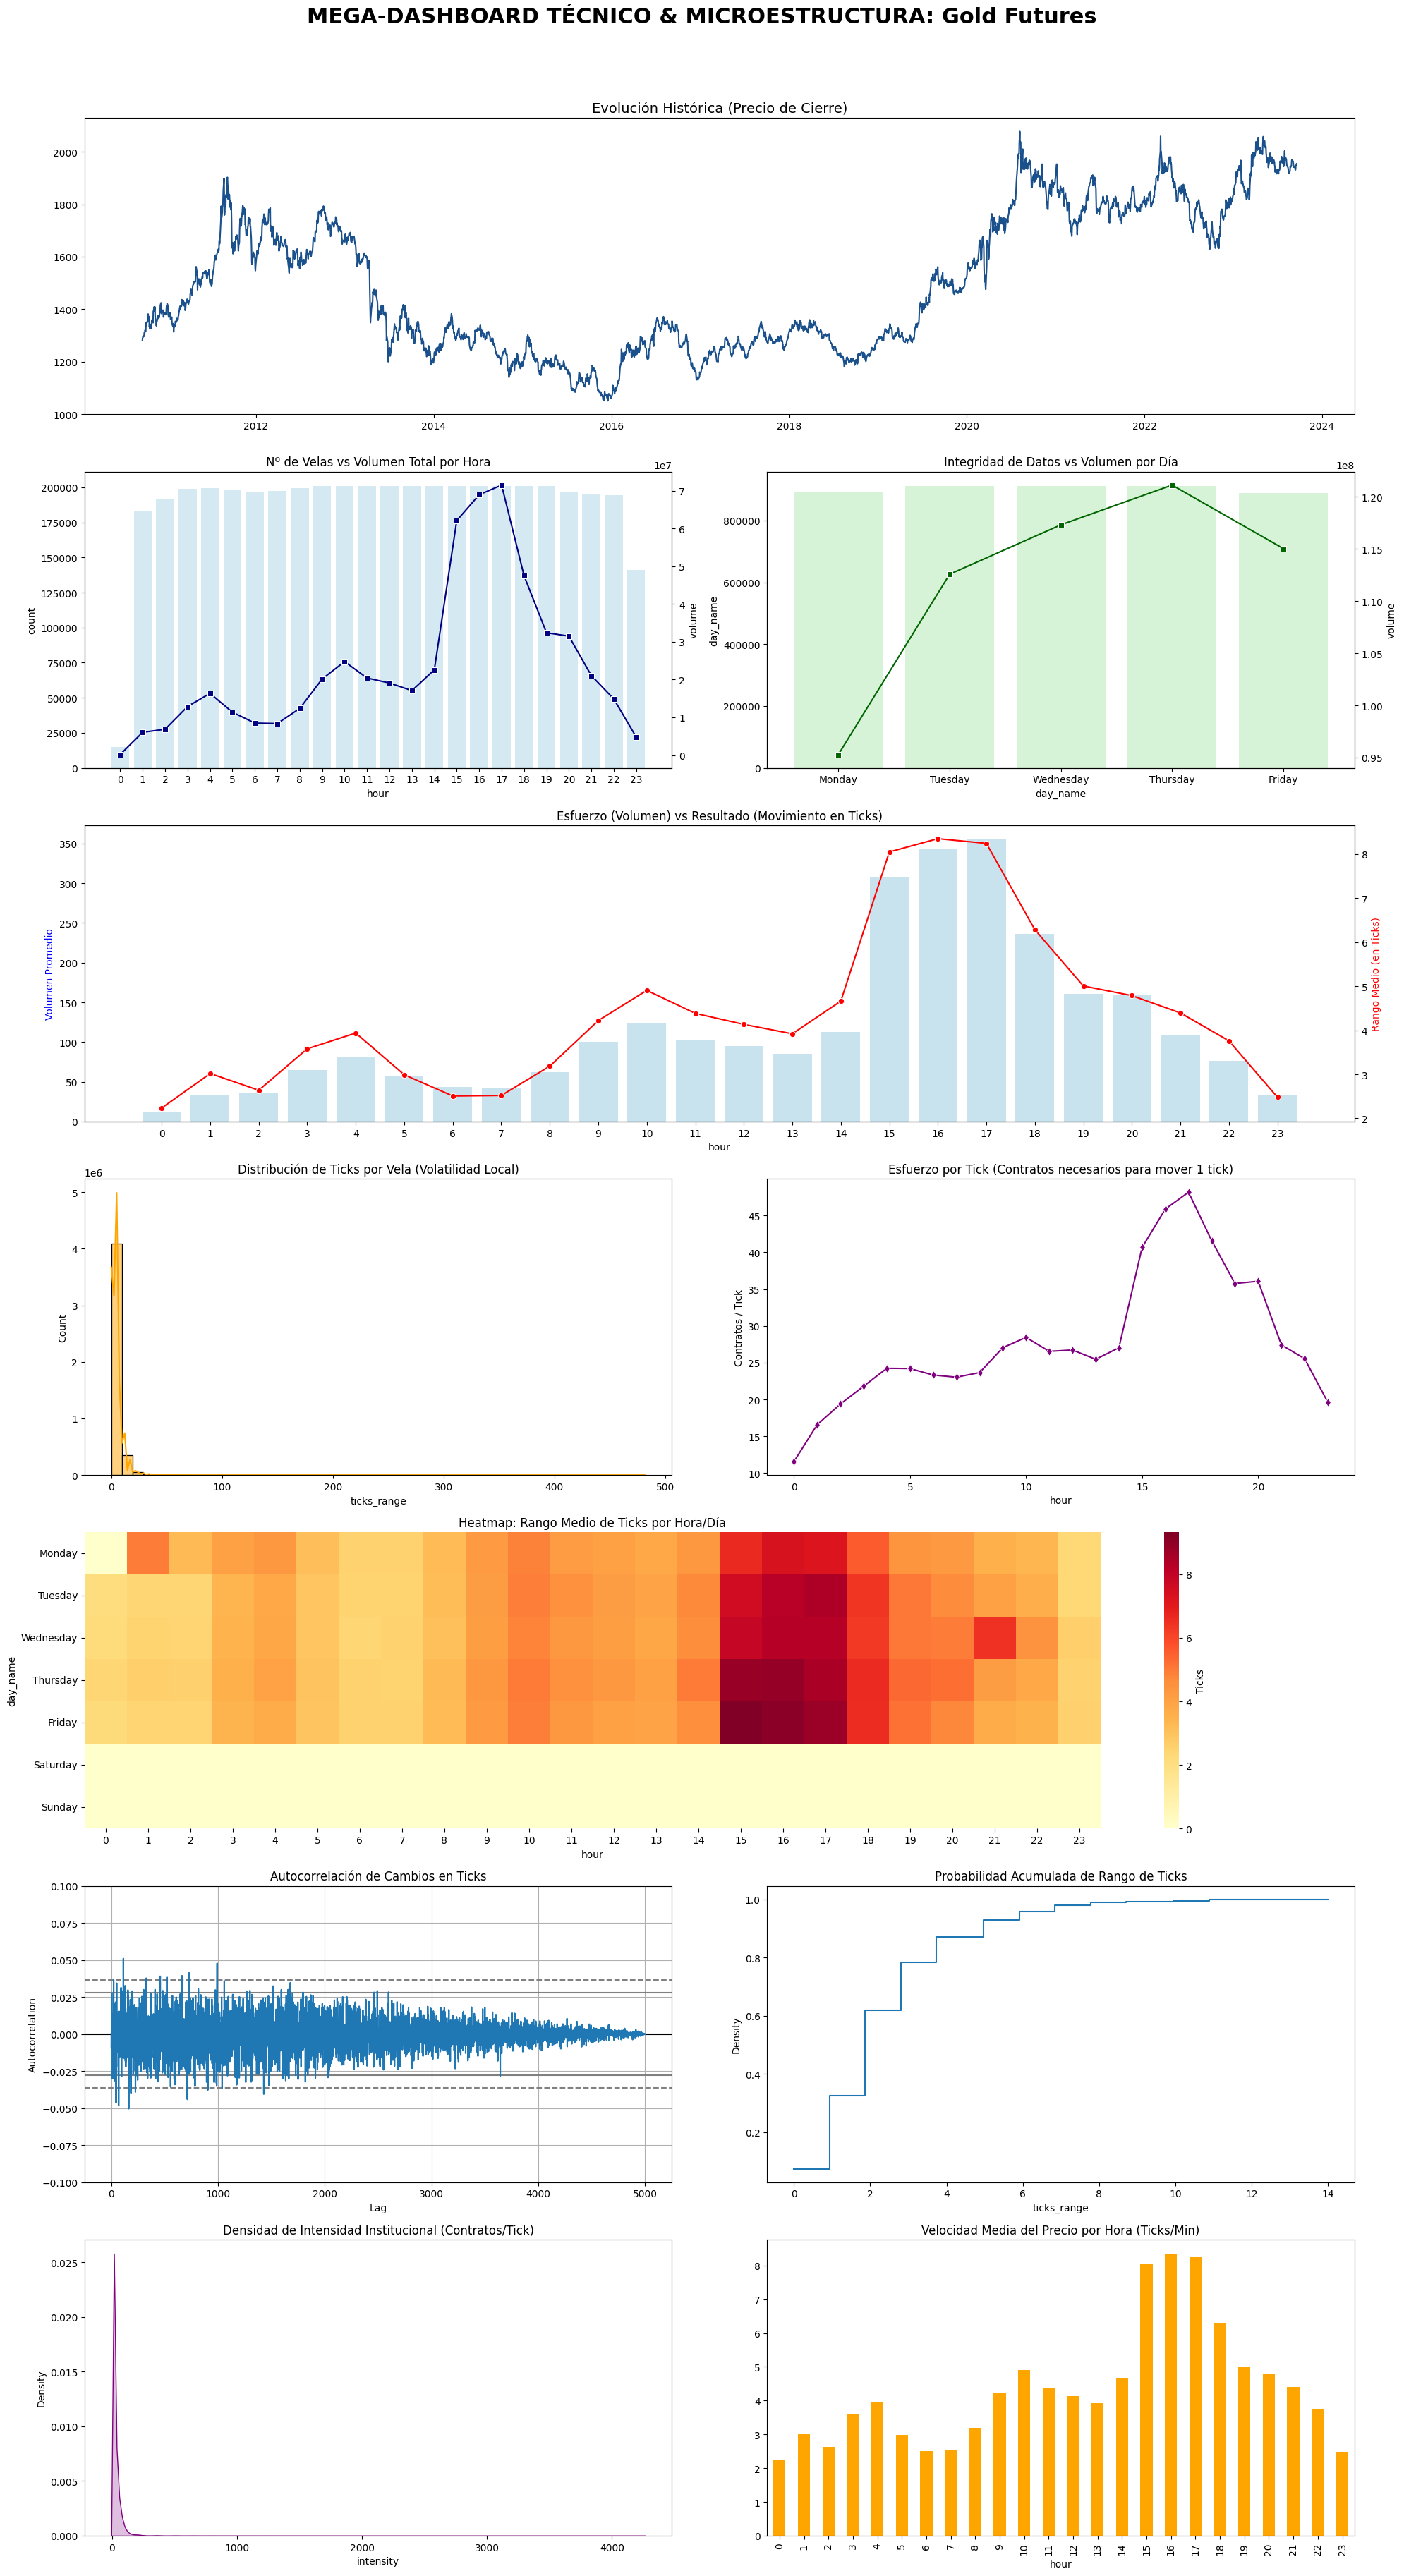

In [10]:
plot_complete_market_analysis_v3(df_min_clean, asset_name="Gold Futures", tick_size=0.1)

In [11]:
def add_advanced_eda_features(df):
    df = df.copy()
    
    # --- 1. VWAP INTRADÍA (Reinicio diario) ---
    # Calculamos el precio típico y el producto precio*volumen
    df['tp'] = (df['high'] + df['low'] + df['close']) / 3
    df['pv'] = df['tp'] * df['volume']
    
    # Agrupamos por fecha para reiniciar el VWAP cada día
    group = df.groupby(df.index.date)
    df['vwap'] = group['pv'].cumsum() / group['volume'].cumsum()
    
    # Desviación del VWAP (Z-Score)
    # Esto te dice qué tan "caro" o "barato" está respecto al promedio del día
    df['vwap_std'] = group['tp'].transform(lambda x: x.expanding().std())
    df['vwap_zscore'] = (df['close'] - df['vwap']) / (df['vwap_std'] + 0.001)

    # --- 2. EFICIENCIA DEL MOVIMIENTO (Fractal) ---
    # Medimos en ventanas de 30 min si el movimiento es direccional o ruido
    lookback_eff = 30
    df['net_change'] = df['close'].diff(lookback_eff).abs()
    df['total_path'] = df['close'].diff().abs().rolling(window=lookback_eff).sum()
    df['efficiency_ratio'] = df['net_change'] / (df['total_path'] + 0.001)
    
    return df

# Puedes añadir estas gráficas en una nueva fila al final de tu función actual:
# ax_vwap = fig.add_subplot(gs[row, 0])
# sns.histplot(df_diag['vwap_zscore'].dropna(), kde=True, ax=ax_vwap, color='teal')
# ax_vwap.set_title("Distribución de Desviación del VWAP (Z-Score)")

# ax_eff = fig.add_subplot(gs[row, 1])
# df_diag.groupby('hour')['efficiency_ratio'].mean().plot(ax=ax_eff, color='gold')
# ax_eff.set_title("Eficiencia del Movimiento por Hora (Direccionalidad)")

In [12]:
def plot_master_market_analysis(df, asset_name="Future", tick_size=0.1, 
                                price_plots=True, tick_plots=True, max_autocorr=10000):
    df_diag = df.copy()
    df_diag.columns = df_diag.columns.str.strip().str.lower()
    
    # 1. Preparación de Datetime
    if 'datetime' in df_diag.columns:
        df_diag['datetime'] = pd.to_datetime(df_diag['datetime'])
        df_diag = df_diag.set_index('datetime')
    else:
        df_diag.index = pd.to_datetime(df_diag.index)

    # 2. Cálculo de Columnas Auxiliares y Microestructura
    df_diag['hour'] = df_diag.index.hour
    df_diag['day_name'] = df_diag.index.day_name()
    df_diag['volatility'] = df_diag['high'] - df_diag['low']
    df_diag['ticks_range'] = df_diag['volatility'] / tick_size
    
    # --- CÁLCULOS AVANZADOS (VWAP & EFICIENCIA) ---
    # VWAP Intradía (se reinicia cada día)
    df_diag['tp'] = (df_diag['high'] + df_diag['low'] + df_diag['close']) / 3
    df_diag['pv'] = df_diag['tp'] * df_diag['volume']
    
    # Agrupamos por fecha para el acumulado diario
    date_group = df_diag.groupby(df_diag.index.date)
    df_diag['vwap'] = date_group['pv'].cumsum() / date_group['volume'].cumsum()
    
    # Z-Score del VWAP (Desviación)
    vwap_std = date_group['tp'].transform(lambda x: x.expanding().std())
    df_diag['vwap_zscore'] = (df_diag['close'] - df_diag['vwap']) / (vwap_std + 0.001)
    
    # Efficiency Ratio (Fractalidad a 30 min)
    lookback_eff = 30
    net_chg = df_diag['close'].diff(lookback_eff).abs()
    path_chg = df_diag['close'].diff().abs().rolling(window=lookback_eff).sum()
    df_diag['efficiency_ratio'] = net_chg / (path_chg + 0.001)

    # Métricas de Ticks
    df_diag['vol_per_tick'] = df_diag['volume'] / (df_diag['ticks_range'] + 0.1)
    df_diag['intensity'] = df_diag['vol_per_tick']
    df_diag['speed'] = df_diag['ticks_range'] # Ticks por minuto

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # 3. Definición Dinámica de la Rejilla (Grid)
    price_rows = 5 if price_plots else 0
    tick_rows = 6 if tick_plots else 0 # Aumentado para VWAP y Speed
    total_rows = price_rows + tick_rows
    
    fig = plt.figure(figsize=(18, 4 * total_rows))
    gs = fig.add_gridspec(total_rows, 2)
    plt.suptitle(f"MASTER DASHBOARD PROFESIONAL: {asset_name}", fontsize=22, y=0.99, fontweight='bold')

    row = 0
    
    # --- SECCIÓN DE PRECIO ---
    if price_plots:
        # Fila 1: Precio Diario
        ax0 = fig.add_subplot(gs[row, :])
        df_daily = df_diag['close'].resample('D').last().dropna()
        ax0.plot(df_daily.index, df_daily.values, color='#1a508b', linewidth=1.5)
        ax0.set_title("Evolución del Precio (Cierre Diario)")
        row += 1

        # Fila 2: Volumen y Frecuencia
        ax1 = fig.add_subplot(gs[row, 0])
        stats_h = df_diag.groupby('hour').agg({'volume': 'sum', 'hour': 'count'}).rename(columns={'hour': 'count'})
        sns.barplot(x=stats_h.index, y=stats_h['count'], color='skyblue', ax=ax1, alpha=0.6)
        ax1_t = ax1.twinx()
        sns.lineplot(x=stats_h.index, y=stats_h['volume'], color='navy', marker='o', ax=ax1_t)
        ax1.set_title("Nº Velas vs Volumen por Hora")

        ax2 = fig.add_subplot(gs[row, 1])
        stats_d = df_diag.groupby('day_name').agg({'volume': 'sum', 'day_name': 'count'}).reindex(days_order).dropna()
        sns.barplot(x=stats_d.index, y=stats_d['day_name'], color='lightgreen', ax=ax2, alpha=0.6)
        ax2_t = ax2.twinx()
        sns.lineplot(x=stats_d.index, y=stats_d['volume'], color='darkgreen', marker='o', ax=ax2_t)
        ax2.set_title("Integridad de Datos por Día")
        row += 1

        # Fila 3: Wyckoff (Esfuerzo/Resultado)
        ax3 = fig.add_subplot(gs[row, :])
        h_stats = df_diag.groupby('hour').agg({'volume': 'mean', 'volatility': 'mean'})
        sns.barplot(x=h_stats.index, y=h_stats['volume'], color='skyblue', alpha=0.5, ax=ax3)
        ax3_t = ax3.twinx()
        sns.lineplot(x=h_stats.index, y=h_stats['volatility'], color='red', marker='o', ax=ax3_t)
        ax3.set_title("Esfuerzo (Volumen) vs Resultado (Volatilidad)")
        row += 1

        # Fila 4: Heatmap
        ax4 = fig.add_subplot(gs[row, :])
        hmap = df_diag.groupby(['day_name', 'hour'])['volatility'].mean().unstack().reindex(days_order).fillna(0)
        sns.heatmap(hmap, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Ticks'})
        ax4.set_title("Heatmap: Volatilidad Horaria")
        row += 1

        # Fila 5: Autocorr y Gaps
        ax_ac = fig.add_subplot(gs[row, 0])
        returns = np.log(df_diag['close'] / df_diag['close'].shift(1)).dropna()
        pd.plotting.autocorrelation_plot(returns.tail(max_autocorr), ax=ax_ac)
        ax_ac.set_ylim(-0.05, 0.05)
        ax_ac.set_title("Autocorrelación (Memoria)")

        ax_gap = fig.add_subplot(gs[row, 1])
        df_gap = df_diag.resample('D').agg({'open': 'first', 'close': 'last'}).dropna()
        df_gap['gap'] = df_gap['open'] - df_gap['close'].shift(1)
        sns.histplot(df_gap['gap'].dropna(), kde=True, color='purple', ax=ax_gap)
        ax_gap.set_title("Distribución de Gaps")
        row += 1

    # --- SECCIÓN DE TICKS & MICROESTRUCTURA ---
    if tick_plots:
        # Fila 6: Distribución e Intensidad
        ax_t1 = fig.add_subplot(gs[row, 0])
        sns.histplot(df_diag['ticks_range'].dropna(), bins=50, kde=True, color='orange', ax=ax_t1)
        ax_t1.set_title("Distribución de Ticks por Vela")

        ax_t2 = fig.add_subplot(gs[row, 1])
        h_vol_tick = df_diag.groupby('hour')['vol_per_tick'].mean()
        sns.lineplot(x=h_vol_tick.index, y=h_vol_tick.values, marker='d', color='purple', ax=ax_t2)
        ax_t2.set_title("Contratos por Tick (Institucional)")
        row += 1

        # Fila 7: Heatmap Ticks
        ax_t3 = fig.add_subplot(gs[row, :])
        hmap_t = df_diag.groupby(['day_name', 'hour'])['ticks_range'].mean().unstack().reindex(days_order).fillna(0)
        sns.heatmap(hmap_t, cmap='YlOrRd', ax=ax_t3)
        ax_t3.set_title("Heatmap: Rango Medio de Ticks")
        row += 1

        # Fila 8: Densidad e Integridad
        ax_t4 = fig.add_subplot(gs[row, 0])
        sns.kdeplot(df_diag['intensity'].dropna(), fill=True, color='purple', ax=ax_t4)
        ax_t4.set_title("Densidad de Intensidad (Contratos/Tick)")

        ax_t5 = fig.add_subplot(gs[row, 1])
        sns.ecdfplot(df_diag['ticks_range'].dropna().clip(upper=df_diag['ticks_range'].quantile(0.99)), ax=ax_t5, color='brown')
        ax_t5.set_title("ECDF: Rango de Ticks (99% Perc)")
        row += 1

        # Fila 9: Velocidad y Eficiencia
        ax_speed = fig.add_subplot(gs[row, 0])
        df_diag.groupby('hour')['speed'].mean().plot(kind='bar', ax=ax_speed, color='orange', alpha=0.7)
        ax_speed.set_title("Velocidad Media (Ticks/Min)")

        ax_eff = fig.add_subplot(gs[row, 1])
        df_diag.groupby('hour')['efficiency_ratio'].mean().plot(ax=ax_eff, color='gold', marker='s')
        ax_eff.set_title("Eficiencia del Movimiento (Trend vs Noise)")
        row += 1

        # Fila 10: Análisis de VWAP
        ax_vwap = fig.add_subplot(gs[row, :])
        sns.histplot(df_diag['vwap_zscore'].dropna(), kde=True, ax=ax_vwap, color='teal')
        ax_vwap.set_title("Z-Score del VWAP (Desviación del Precio Justo)")
        row += 1

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    # return df_diag

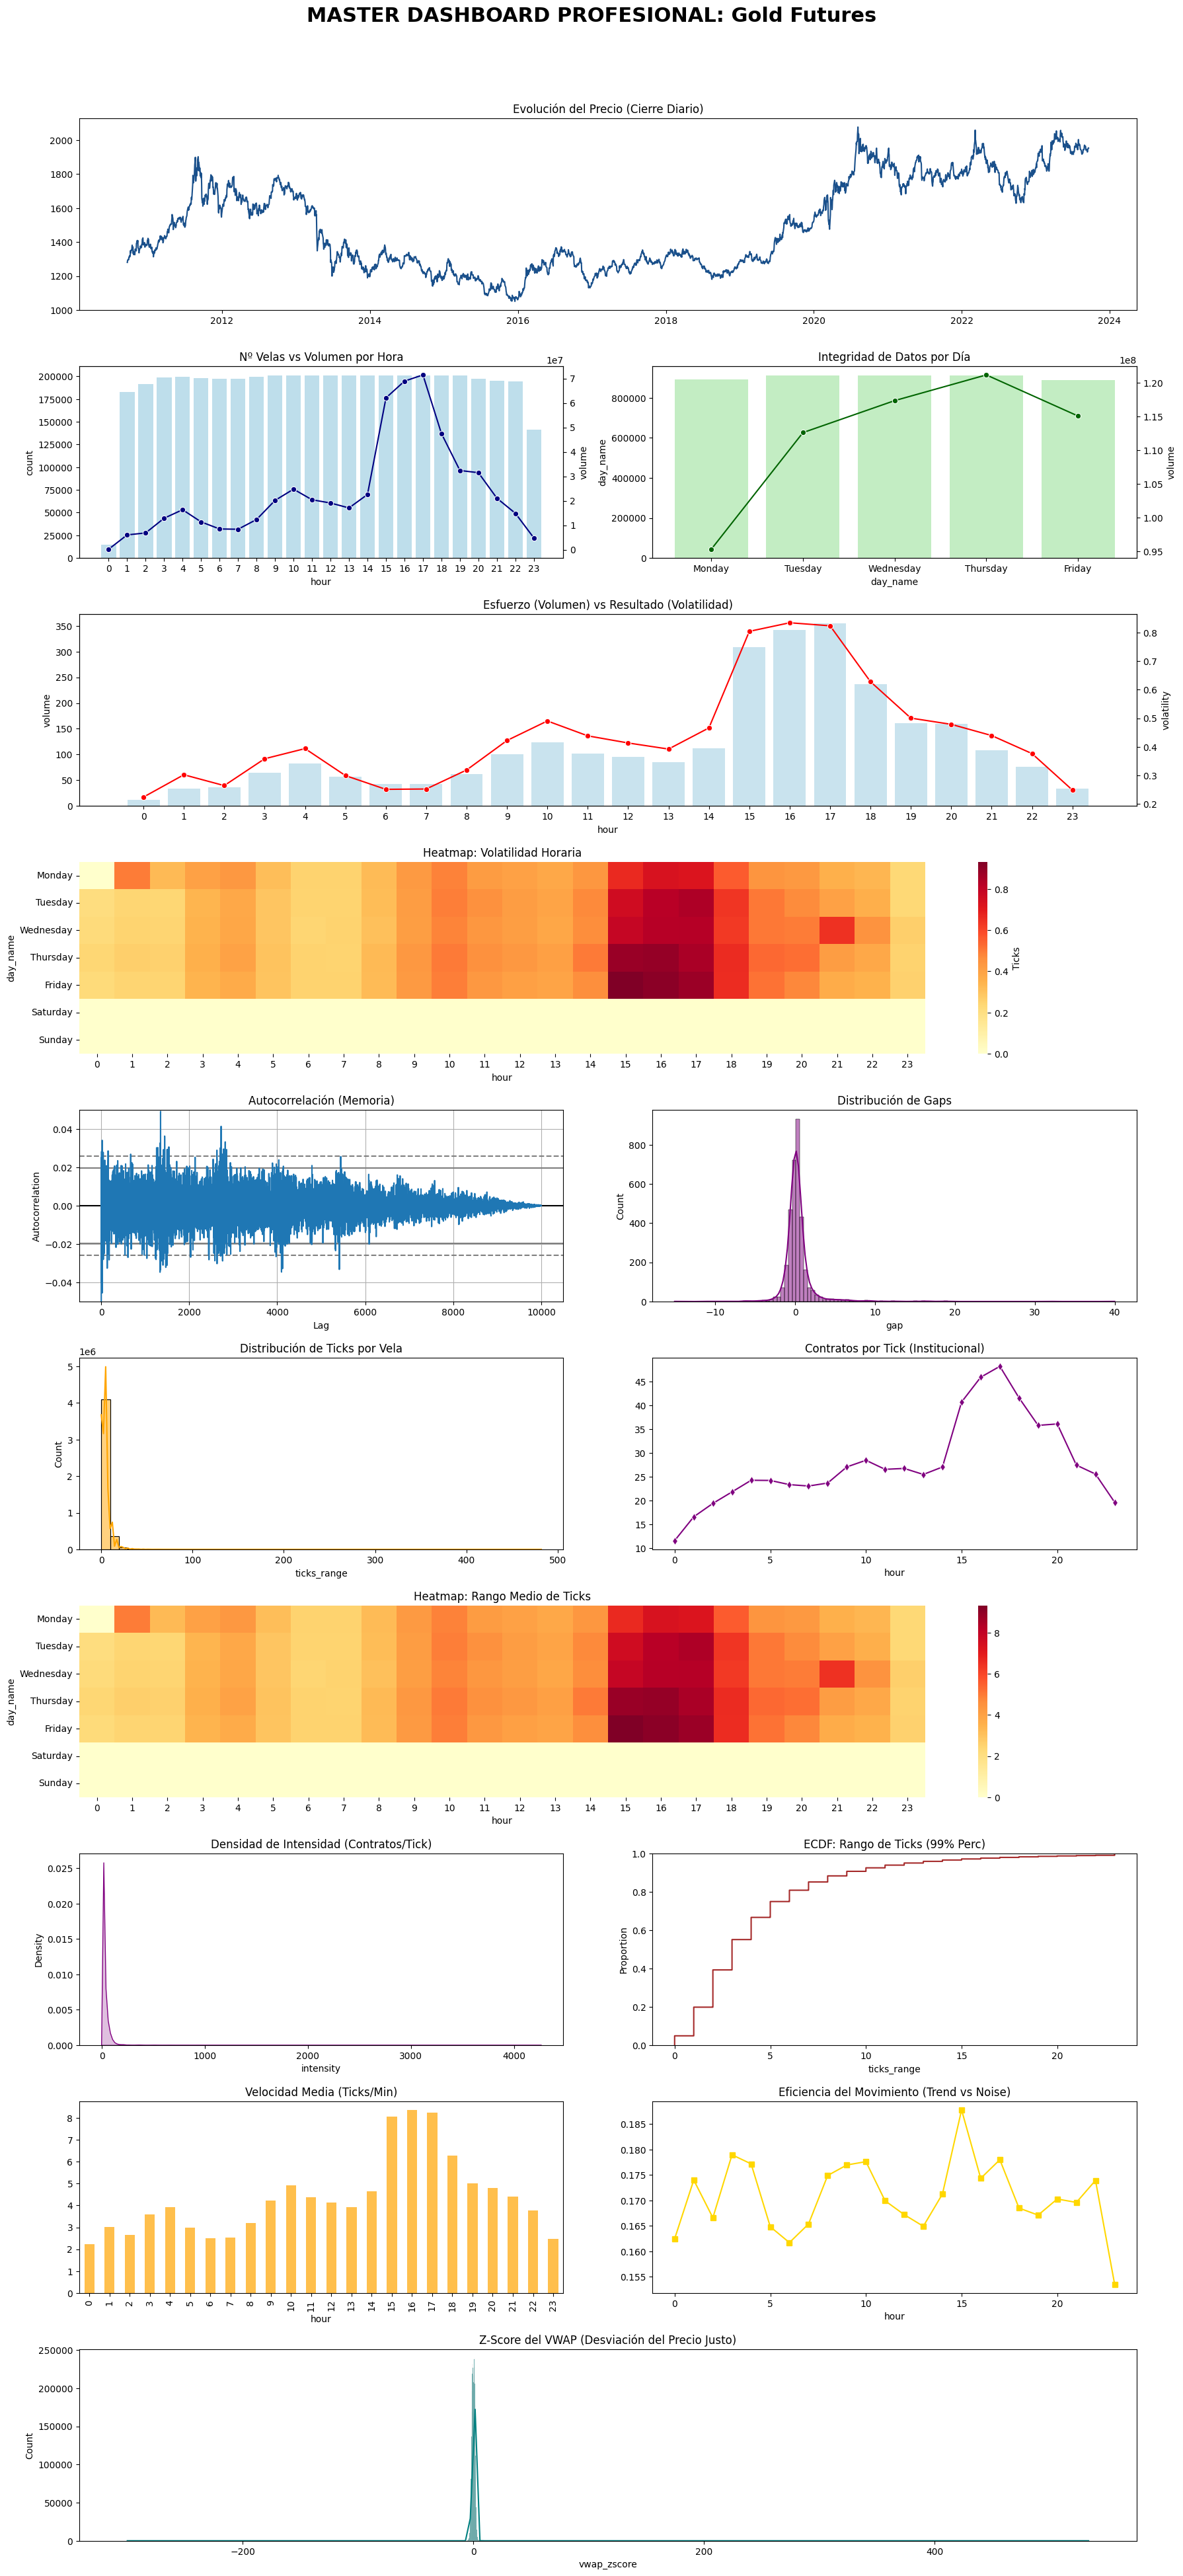

In [13]:
plot_master_market_analysis(df_min_clean, asset_name="Gold Futures", tick_size=0.1)

In [18]:
df_min_clean_30min = resample_ohlcv(df_min_clean, period='30min')

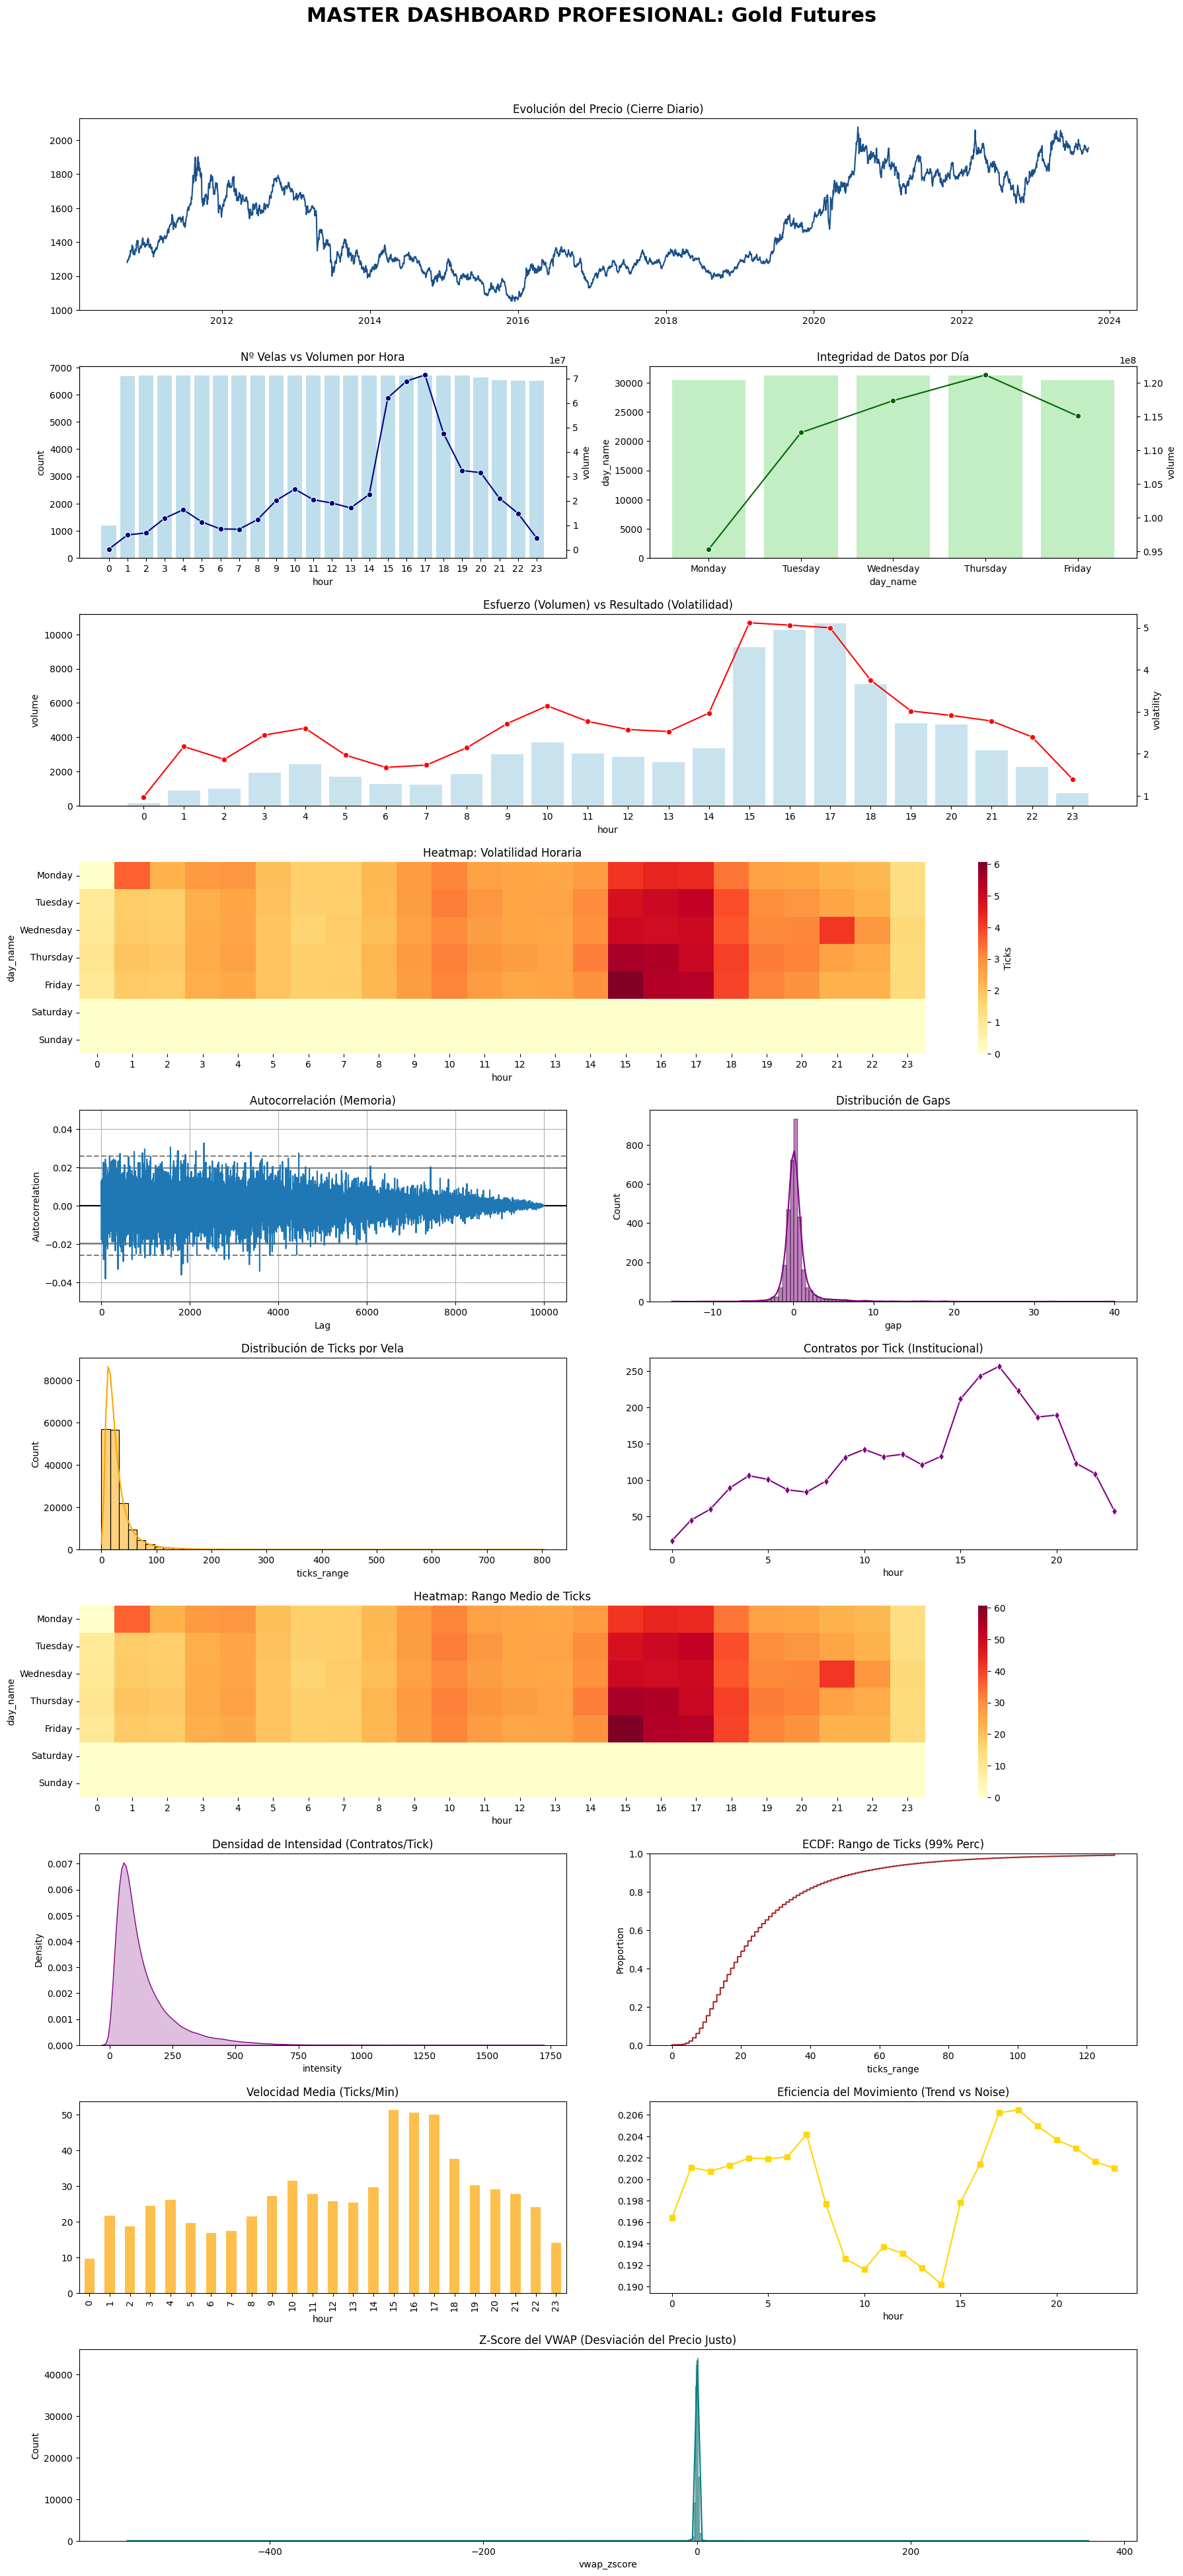

In [19]:
plot_master_market_analysis(df_min_clean_30min, asset_name="Gold Futures", tick_size=0.1)